# ECE 569A Project Notebook
## AI Customer IT Support Ticket Classification, Prioritization, and Routing


## 1. Import and setting

In [ ]:
# Colab setup
# If a package is already installed, pip will skip it quickly.
!pip -q install kagglehub seaborn wordcloud scikit-learn

In [ ]:
import os
import re
import json
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import kagglehub

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42

## 2. Download the Dataset

For this experiment, we use dataset file:

- `aa_dataset-tickets-multi-lang-5-2-50-version.csv`

We then keep only the English tickets (`language == "en"`) for training and evaluation.


In [ ]:
# Download latest version
path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'multilingual-customer-support-tickets' dataset.
Path to dataset files: /kaggle/input/multilingual-customer-support-tickets


In [ ]:
print(os.listdir(path))


['dataset-tickets-multi-lang-4-20k.csv', 'dataset-tickets-german_normalized_50_5_2.csv', 'dataset-tickets-multi-lang3-4k.csv', 'dataset-tickets-german_normalized.csv', 'aa_dataset-tickets-multi-lang-5-2-50-version.csv']


## 3. Load the English Subset from the Richer-Schema CSV



In [ ]:
from pathlib import Path

target_filename = "aa_dataset-tickets-multi-lang-5-2-50-version.csv"
csv_path = None

for f in Path(path).rglob(target_filename):
    csv_path = f
    break

if csv_path is None:
    raise FileNotFoundError(f"Could not find {target_filename} in the downloaded dataset.")

print("Using CSV:", csv_path)
df = pd.read_csv(csv_path)
print("Raw shape:", df.shape)

df = df[df["language"].astype(str).str.lower() == "en"].copy()
df = df.reset_index(drop=True)

print("English-only shape:", df.shape)
df.head()


Using CSV: /kaggle/input/multilingual-customer-support-tickets/aa_dataset-tickets-multi-lang-5-2-50-version.csv
Raw shape: (28587, 16)
English-only shape: (16338, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management ...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, ...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed informati...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit....",Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about ...",We appreciate you reaching out with your billing questions. The billing period generally begins on the first day of ...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your...","Thank you for your inquiry. Our product supports integration with major CRM, email marketing, and analytics platform...",Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the feature...","Thank you for your inquiry. Please specify which product you are interested in, so I can provide detailed informatio...",Request,Technical Support,high,en,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:")
for col in df.columns:
    print("-", col)


Dataset shape: (16338, 16)

Columns:
- subject
- body
- answer
- type
- queue
- priority
- language
- version
- tag_1
- tag_2
- tag_3
- tag_4
- tag_5
- tag_6
- tag_7
- tag_8


## 4. Confirm the Columns



In [ ]:
df.columns.tolist()


['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'version',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

## 5. Initial Data Quality Check

In [ ]:
summary_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])
summary_df

,dtype,missing_count,missing_pct,n_unique
tag_8,object,16057,98.28,135
tag_7,object,15204,93.06,282
tag_6,object,12968,79.37,399
tag_5,object,7922,48.49,441
subject,object,2607,15.96,13731
tag_4,object,1711,10.47,390
tag_3,object,69,0.42,303
tag_2,object,6,0.04,197
answer,object,3,0.02,16335
body,object,0,0.00,16338


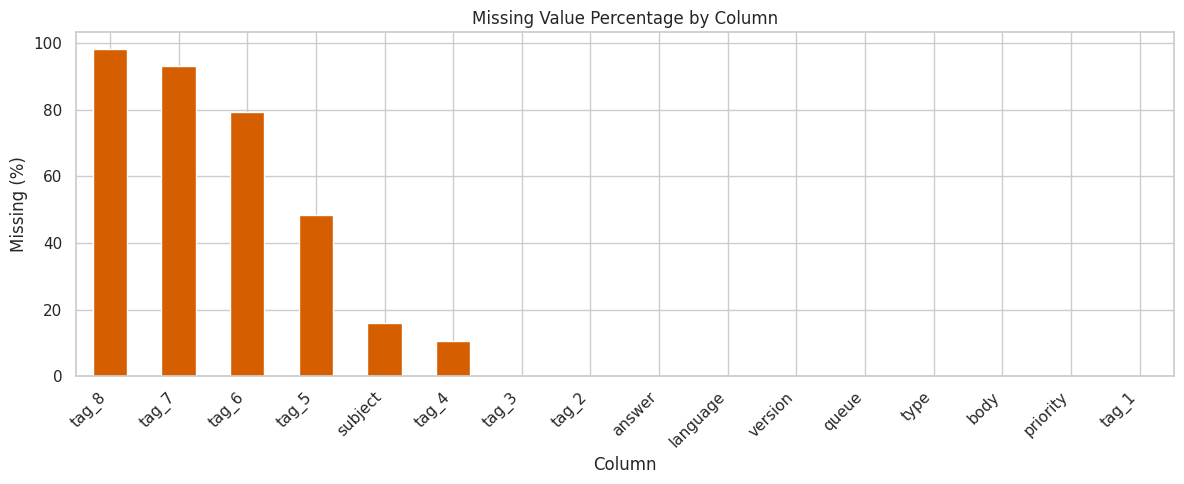

In [ ]:
plt.figure(figsize=(12, 5))
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.plot(kind="bar", color="#D55E00")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Missing (%)")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Simpify  Columns


In [ ]:
subject_col = "subject"
body_col = "body"
type_col = "type"
priority_col = "priority"
queue_col = "queue"
language_col = "language"
business_type_col = "business_type" if "business_type" in df.columns else None

selected_columns = {
    "subject_col": subject_col,
    "body_col": body_col,
    "type_col": type_col,
    "priority_col": priority_col,
    "queue_col": queue_col,
    "language_col": language_col,
    "business_type_col": business_type_col,
}
print(json.dumps(selected_columns, indent=2))


{
  "subject_col": "subject",
  "body_col": "body",
  "type_col": "type",
  "priority_col": "priority",
  "queue_col": "queue",
  "language_col": "language",
  "business_type_col": null
}


## 7. Create a Clean Working Table

In [ ]:
work_df = df.copy()

work_df[subject_col] = work_df[subject_col].fillna("").astype(str)
work_df[body_col] = work_df[body_col].fillna("").astype(str)

work_df["combined_text"] = (
    work_df[subject_col].str.strip() + " " + work_df[body_col].str.strip()
).str.strip()

work_df["combined_text"] = work_df["combined_text"].fillna("")
work_df["text_char_len"] = work_df["combined_text"].str.len()
work_df["text_word_len"] = work_df["combined_text"].str.split().str.len()

work_df = work_df[work_df["combined_text"].str.strip().ne("")].copy()
work_df.reset_index(drop=True, inplace=True)

print("Working dataset shape:", work_df.shape)
display_columns = [c for c in [subject_col, body_col, "combined_text", type_col, priority_col, queue_col, language_col, business_type_col] if c is not None]
work_df[display_columns].head()


Working dataset shape: (16338, 19)


,subject,body,combined_text,type,priority,queue,language
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management ...","Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized ...",Incident,high,Technical Support,en
1,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed informati...","Query About Smart Home System Integration Features Dear Customer Support Team,\n\nI hope this message reaches you we...",Request,medium,Returns and Exchanges,en
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about ...","Inquiry Regarding Invoice Details Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching o...",Request,low,Billing and Payments,en
3,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your...","Question About Marketing Agency Software Compatibility Dear Support Team,\n\nI hope this message reaches you well. I...",Problem,medium,Sales and Pre-Sales,en
4,Feature Query,"Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the feature...","Feature Query Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more abo...",Request,high,Technical Support,en


## 8. Exploratory Data Analysis (EDA)


In [ ]:
work_df[["text_char_len", "text_word_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
text_char_len,16338.0,405.376423,179.676721,18.0,254.25,416.0,565.0,1189.0
text_word_len,16338.0,58.643041,26.868554,2.0,36.00,60.0,82.0,172.0


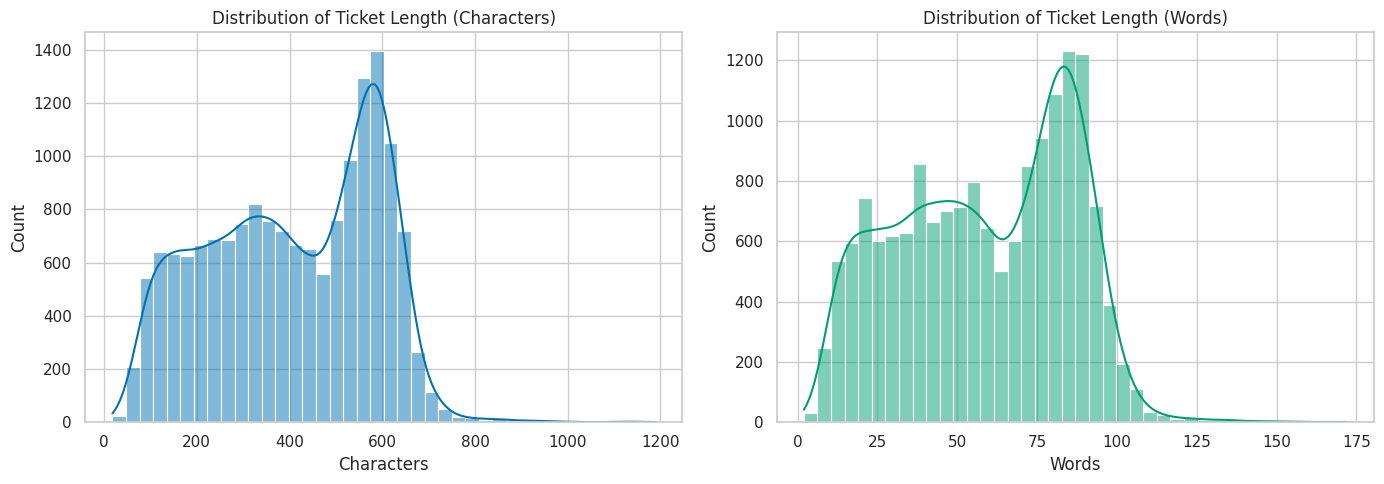

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(work_df["text_char_len"], bins=40, kde=True, ax=axes[0], color="#0072B2")
axes[0].set_title("Distribution of Ticket Length (Characters)")
axes[0].set_xlabel("Characters")

sns.histplot(work_df["text_word_len"], bins=40, kde=True, ax=axes[1], color="#009E73")
axes[1].set_title("Distribution of Ticket Length (Words)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

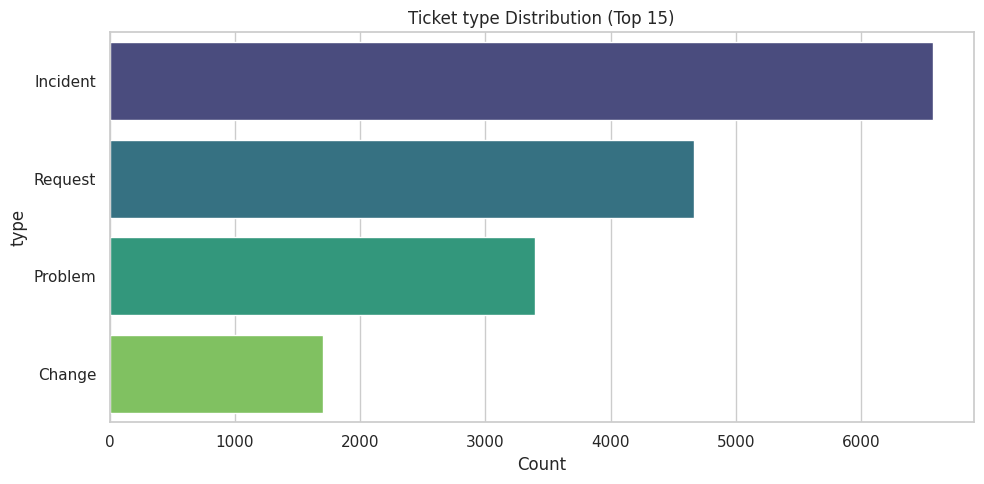

,count
type,
Incident,6571
Request,4665
Problem,3397
Change,1705


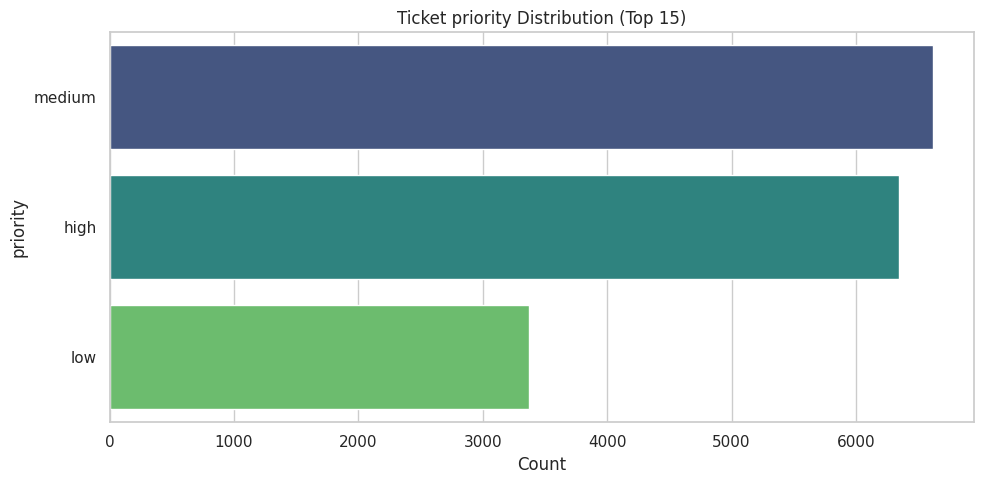

,count
priority,
medium,6618
high,6346
low,3374


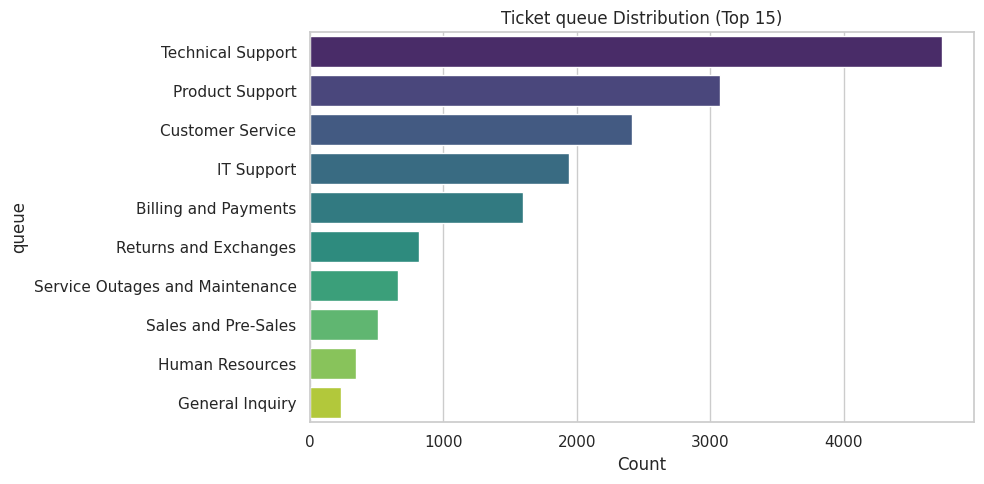

,count
queue,
Technical Support,4737
Product Support,3073
Customer Service,2410
IT Support,1942
Billing and Payments,1595
Returns and Exchanges,820
Service Outages and Maintenance,664
Sales and Pre-Sales,513
Human Resources,348


In [ ]:
def plot_top_categories(data, column, top_n=15, title_prefix=""):
    vc = data[column].fillna("Missing").astype(str).value_counts().head(top_n)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=vc.values, y=vc.index, palette="viridis")
    plt.title(f"{title_prefix}{column} Distribution (Top {top_n})")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()
    display(vc.to_frame("count"))

for col in [type_col, priority_col, queue_col] + ([business_type_col] if business_type_col is not None else []):
    plot_top_categories(work_df, col, title_prefix="Ticket " if col in [type_col, priority_col, queue_col] else "")


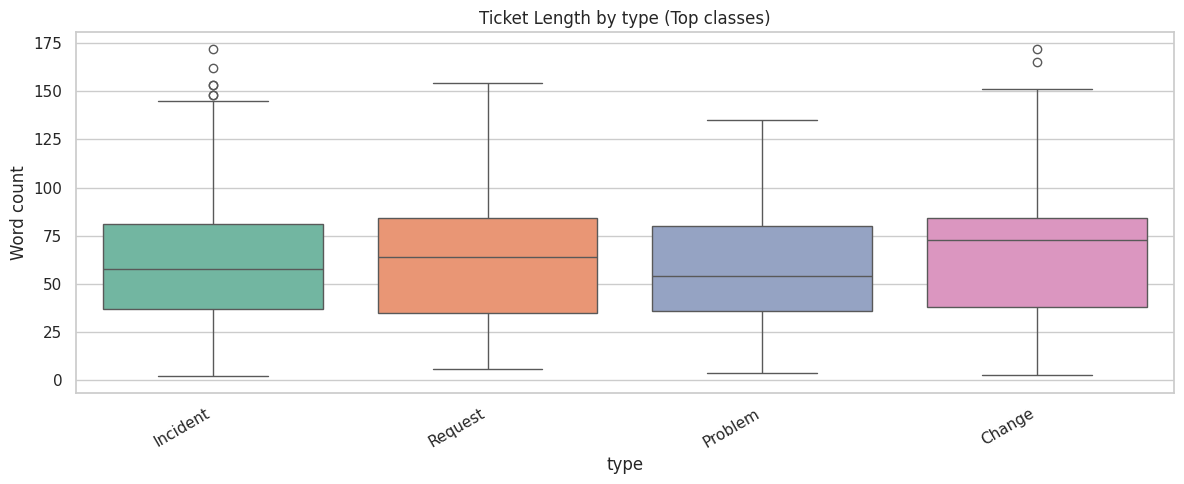

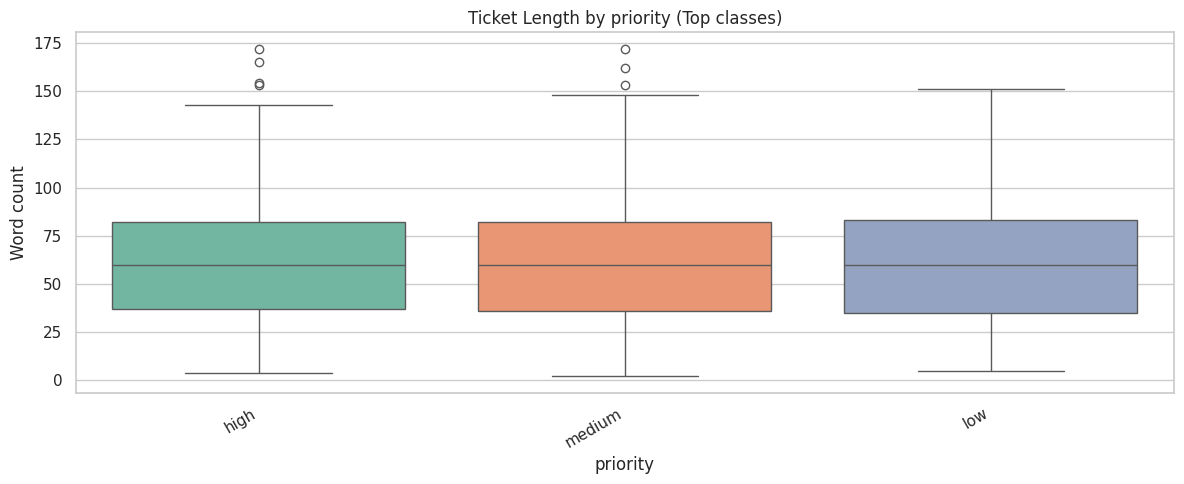

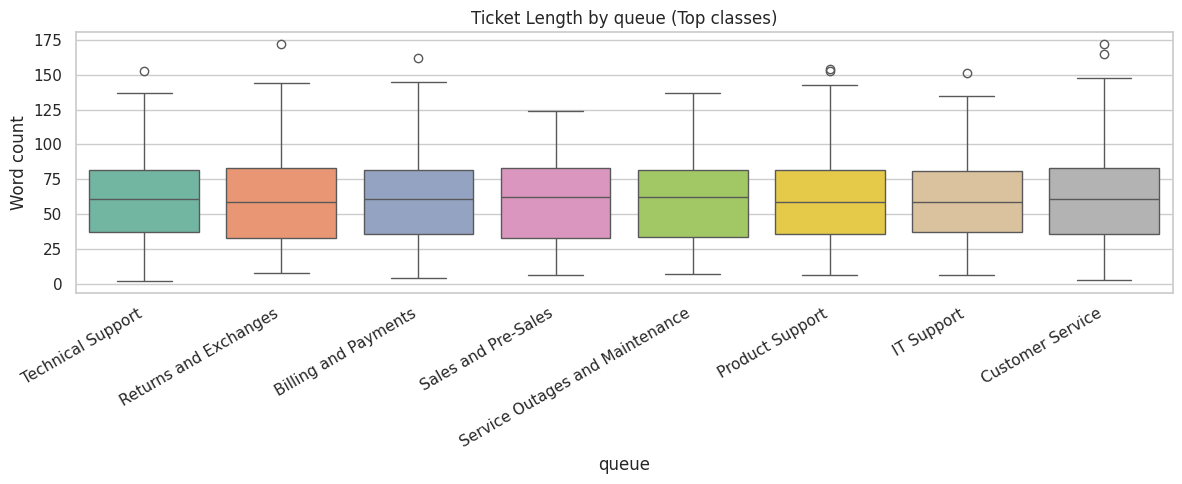

In [ ]:
# Compare ticket length across the main prediction labels.
for target_col in [type_col, priority_col, queue_col]:
    top_labels = work_df[target_col].astype(str).value_counts().head(8).index
    subset = work_df[work_df[target_col].astype(str).isin(top_labels)].copy()

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=subset, x=target_col, y="text_word_len", palette="Set2")
    plt.title(f"Ticket Length by {target_col} (Top classes)")
    plt.xlabel(target_col)
    plt.ylabel("Word count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


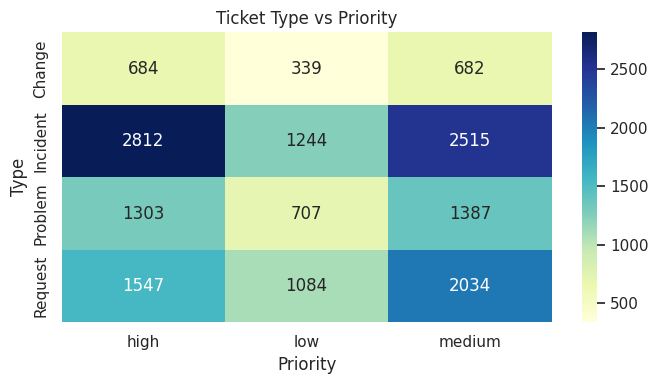

priority,high,low,medium
type,,,
Change,684,339,682
Incident,2812,1244,2515
Problem,1303,707,1387
Request,1547,1084,2034


In [ ]:
type_priority_ct = pd.crosstab(work_df[type_col], work_df[priority_col])
plt.figure(figsize=(7, 4))
sns.heatmap(type_priority_ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Ticket Type vs Priority")
plt.xlabel("Priority")
plt.ylabel("Type")
plt.tight_layout()
plt.show()
display(type_priority_ct)


In [ ]:
avg_length_by_priority = work_df.groupby(priority_col)[["text_char_len", "text_word_len"]].mean().round(2).sort_values("text_word_len", ascending=False)
avg_length_by_language = work_df.groupby(language_col)[["text_char_len", "text_word_len"]].mean().round(2).sort_values("text_word_len", ascending=False)

print("Average text length by priority:")
display(avg_length_by_priority)


Average text length by priority:


,text_char_len,text_word_len
priority,,
high,406.44,58.68
low,403.89,58.68
medium,405.11,58.59


## 9. Prepare Supervised Learning Tasks

In [ ]:
def prepare_task_frame(data, target_col, min_class_size=5):
    if target_col is None or target_col not in data.columns:
        return None

    task_df = data[["combined_text", target_col]].copy()
    task_df = task_df.dropna()
    task_df[target_col] = task_df[target_col].astype(str).str.strip()
    task_df = task_df[task_df[target_col] != ""]

    label_counts = task_df[target_col].value_counts()
    keep_labels = label_counts[label_counts >= min_class_size].index
    task_df = task_df[task_df[target_col].isin(keep_labels)].copy()
    task_df.reset_index(drop=True, inplace=True)
    return task_df


tasks = {
    "ticket_type": prepare_task_frame(work_df, type_col),
    "priority": prepare_task_frame(work_df, priority_col),
    "queue": prepare_task_frame(work_df, queue_col),
}

for task_name, task_df in tasks.items():
    if task_df is None or task_df.empty:
        print(f"{task_name}: not available")
    else:
        print(f"{task_name}: {task_df.shape[0]} rows, {task_df.iloc[:,1].nunique()} classes")

ticket_type: 16338 rows, 4 classes
priority: 16338 rows, 3 classes
queue: 16338 rows, 10 classes


## 10. TF-IDF Baseline Modeling


In [ ]:
def train_and_evaluate_text_baseline(task_df, task_name, target_name):
    X = task_df["combined_text"]
    y = task_df[target_name]

    stratify_y = y if y.nunique() > 1 and y.value_counts().min() >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=stratify_y,
    )

    dummy = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)),
        ("clf", DummyClassifier(strategy="most_frequent")),
    ])

    tfidf_lr = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=1200, class_weight="balanced")),
    ])

    models = {
        "dummy_most_frequent": dummy,
        "tfidf_logistic_regression": tfidf_lr,
    }

    metrics_rows = []
    predictions = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        predictions[model_name] = (y_test, y_pred, model)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="weighted", zero_division=0
        )
        metrics_rows.append({
            "task": task_name,
            "model": model_name,
            "train_size": len(X_train),
            "test_size": len(X_test),
            "n_classes": y.nunique(),
            "accuracy": accuracy_score(y_test, y_pred),
            "weighted_precision": precision,
            "weighted_recall": recall,
            "weighted_f1": f1,
        })

    metrics_df = pd.DataFrame(metrics_rows).sort_values("weighted_f1", ascending=False)
    return metrics_df, predictions

all_metrics = []
all_predictions = {}

for task_name, task_df in tasks.items():
    if task_df is None or task_df.empty:
        continue
    target_name = task_df.columns[1]
    metrics_df, preds = train_and_evaluate_text_baseline(task_df, task_name, target_name)
    all_metrics.append(metrics_df)
    all_predictions[task_name] = {"target_name": target_name, "predictions": preds, "data": task_df}

results_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
results_df

,task,model,train_size,test_size,n_classes,accuracy,weighted_precision,weighted_recall,weighted_f1
0,ticket_type,tfidf_logistic_regression,13070,3268,4,0.845471,0.856664,0.845471,0.848331
1,ticket_type,dummy_most_frequent,13070,3268,4,0.402081,0.161669,0.402081,0.230613
2,priority,tfidf_logistic_regression,13070,3268,3,0.604345,0.612797,0.604345,0.606515
3,priority,dummy_most_frequent,13070,3268,3,0.405141,0.164139,0.405141,0.233626
4,queue,tfidf_logistic_regression,13070,3268,10,0.500000,0.517005,0.500000,0.501211
5,queue,dummy_most_frequent,13070,3268,10,0.289780,0.083972,0.289780,0.130212


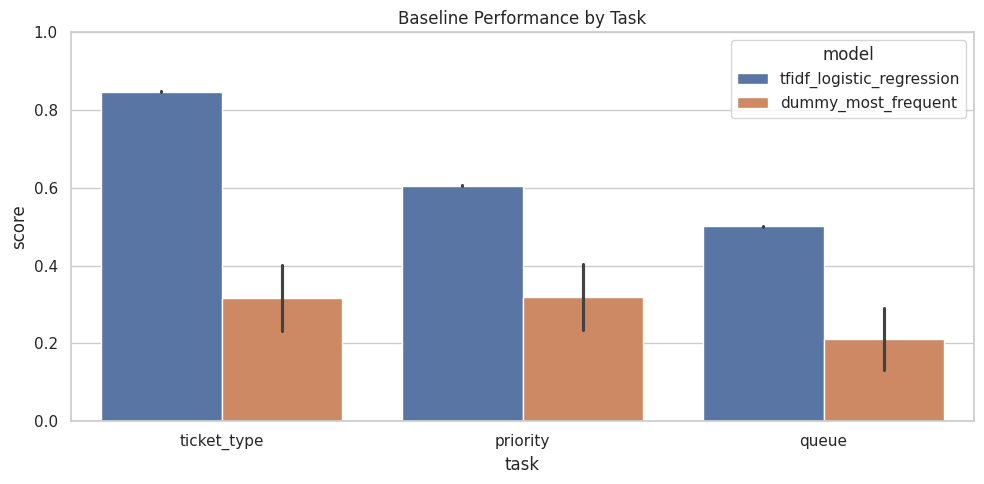

In [ ]:
if not results_df.empty:
    plt.figure(figsize=(10, 5))
    plot_df = results_df.melt(
        id_vars=["task", "model"],
        value_vars=["accuracy", "weighted_f1"],
        var_name="metric",
        value_name="score"
    )
    sns.barplot(data=plot_df, x="task", y="score", hue="model")
    plt.title("Baseline Performance by Task")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()